In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hw.csv"
crop_areas_hw = pd.read_csv(csv_path)
crop_areas_hw

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean
0,djf,1,7.259681e+07,3.054978e+07,3.998411e+07,2.465554e+07,1.950367e+08,3.401520e+07
1,djf,2,7.067639e+07,3.054978e+07,2.887177e+06,2.465554e+07,6.124592e+07,3.401520e+07
2,djf,3,1.263959e+07,3.054978e+07,2.138447e+07,2.465554e+07,1.346227e+07,3.401520e+07
3,djf,4,1.830893e+07,3.054978e+07,4.435331e+07,2.465554e+07,2.740699e+07,3.401520e+07
4,djf,5,3.655739e+07,3.054978e+07,6.345383e+07,2.465554e+07,1.384042e+08,3.401520e+07
...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,5.209342e+06,1.659145e+07
299,son1,47,NaN,NaN,NaN,NaN,2.949166e+06,1.659145e+07
300,son1,48,NaN,NaN,NaN,NaN,2.320769e+07,1.659145e+07
301,son1,49,NaN,NaN,NaN,NaN,9.663248e+06,1.659145e+07


In [3]:
# ENSO years
el_years = [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]
la_years = [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]
ne_years = [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]

In [4]:
# 3. Build mapping dicts
el_map = {i+1: yr for i, yr in enumerate(el_years)}
la_map = {i+1: yr for i, yr in enumerate(la_years)}
ne_map = {i+1: yr for i, yr in enumerate(ne_years)}

# 4. Map into new columns
crop_areas_hw['el_year'] = crop_areas_hw['year_index'].map(el_map)
crop_areas_hw['la_year'] = crop_areas_hw['year_index'].map(la_map)
crop_areas_hw['ne_year'] = crop_areas_hw['year_index'].map(ne_map)

crop_areas_hw

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean,el_year,la_year,ne_year
0,djf,1,7.259681e+07,3.054978e+07,3.998411e+07,2.465554e+07,1.950367e+08,3.401520e+07,1902.0,1903.0,1901
1,djf,2,7.067639e+07,3.054978e+07,2.887177e+06,2.465554e+07,6.124592e+07,3.401520e+07,1904.0,1908.0,1906
2,djf,3,1.263959e+07,3.054978e+07,2.138447e+07,2.465554e+07,1.346227e+07,3.401520e+07,1905.0,1909.0,1907
3,djf,4,1.830893e+07,3.054978e+07,4.435331e+07,2.465554e+07,2.740699e+07,3.401520e+07,1911.0,1910.0,1912
4,djf,5,3.655739e+07,3.054978e+07,6.345383e+07,2.465554e+07,1.384042e+08,3.401520e+07,1913.0,1916.0,1915
...,...,...,...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,5.209342e+06,1.659145e+07,NaN,NaN,2001
299,son1,47,NaN,NaN,NaN,NaN,2.949166e+06,1.659145e+07,NaN,NaN,2003
300,son1,48,NaN,NaN,NaN,NaN,2.320769e+07,1.659145e+07,NaN,NaN,2004
301,son1,49,NaN,NaN,NaN,NaN,9.663248e+06,1.659145e+07,NaN,NaN,2012


In [5]:
# 2. Define the desired season order
season_order = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# 3. Convert 'season' to an ordered categorical
crop_areas_hw['season'] = pd.Categorical(crop_areas_hw['season'], categories=season_order, ordered=True)

# 4. Sort by season (and optionally year_index)
crop_areas_hw = crop_areas_hw.sort_values(['season', 'year_index']).reset_index(drop=True)

crop_areas_hw

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean,el_year,la_year,ne_year
0,jja,1,2.810479e+07,1.939199e+07,4.542299e+07,1.521319e+07,4.087208e+07,1.334361e+07,1902.0,1903.0,1901
1,jja,2,1.021179e+07,1.939199e+07,1.806328e+07,1.521319e+07,2.787593e+07,1.334361e+07,1904.0,1908.0,1906
2,jja,3,2.799367e+07,1.939199e+07,1.062646e+07,1.521319e+07,5.474747e+06,1.334361e+07,1905.0,1909.0,1907
3,jja,4,1.594712e+06,1.939199e+07,3.321908e+07,1.521319e+07,1.250566e+07,1.334361e+07,1911.0,1910.0,1912
4,jja,5,3.010338e+07,1.939199e+07,2.367898e+06,1.521319e+07,4.250942e+07,1.334361e+07,1913.0,1916.0,1915
...,...,...,...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,5.209342e+06,1.659145e+07,NaN,NaN,2001
299,son1,47,NaN,NaN,NaN,NaN,2.949166e+06,1.659145e+07,NaN,NaN,2003
300,son1,48,NaN,NaN,NaN,NaN,2.320769e+07,1.659145e+07,NaN,NaN,2004
301,son1,49,NaN,NaN,NaN,NaN,9.663248e+06,1.659145e+07,NaN,NaN,2012


In [6]:
crop_areas_hw_mean = (
    crop_areas_hw
    .groupby('season')[['el_mean', 'la_mean', 'ne_mean']]
    .mean()
    .reset_index()
)

crop_areas_hw_mean['el_minus_ne'] = crop_areas_hw_mean['el_mean'] - crop_areas_hw_mean['ne_mean']
crop_areas_hw_mean['la_minus_ne'] = crop_areas_hw_mean['la_mean'] - crop_areas_hw_mean['ne_mean']
crop_areas_hw_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne
0,jja,1.939199e+07,1.521319e+07,1.334361e+07,6.048380e+06,1.869576e+06
1,son,2.562284e+07,1.398622e+07,1.588641e+07,9.736430e+06,-1.900192e+06
2,djf,3.054978e+07,2.465554e+07,3.401520e+07,-3.465424e+06,-9.359658e+06
3,mam1,2.463321e+07,1.263820e+07,1.643929e+07,8.193917e+06,-3.801090e+06
4,jja1,2.820409e+07,1.147966e+07,1.100353e+07,1.720057e+07,4.761339e+05
5,son1,2.473910e+07,1.225380e+07,1.659145e+07,8.147652e+06,-4.337648e+06


In [7]:
results = []

for season in crop_areas_hw['season'].cat.categories:
    # select rows for this season
    df_season = crop_areas_hw[crop_areas_hw['season'] == season]
    
    # extract the per‐year series
    el = df_season['el'].dropna().values
    la = df_season['la'].dropna().values
    ne = df_season['ne'].dropna().values
    
    # Mann–Whitney U tests: two‐sided
    p_el_ne = mannwhitneyu(el, ne, alternative='two-sided').pvalue
    p_la_ne = mannwhitneyu(la, ne, alternative='two-sided').pvalue
    
    results.append({
        'season':    season,
        'n_el':      el.size,
        'n_la':      la.size,
        'n_ne':      ne.size,
        'p_el_vs_ne': p_el_ne,
        'p_la_vs_ne': p_la_ne
    })

sig_df = pd.DataFrame(results)
sig_df

,season,n_el,n_la,n_ne,p_el_vs_ne,p_la_vs_ne
0,jja,34,38,51,0.304363,0.884589
1,son,34,38,51,0.295994,0.891141
2,djf,34,38,51,0.703020,0.309591
3,mam1,34,37,50,0.099995,0.096656
4,jja1,34,37,50,0.000601,0.562239
5,son1,34,37,50,0.404376,0.049788


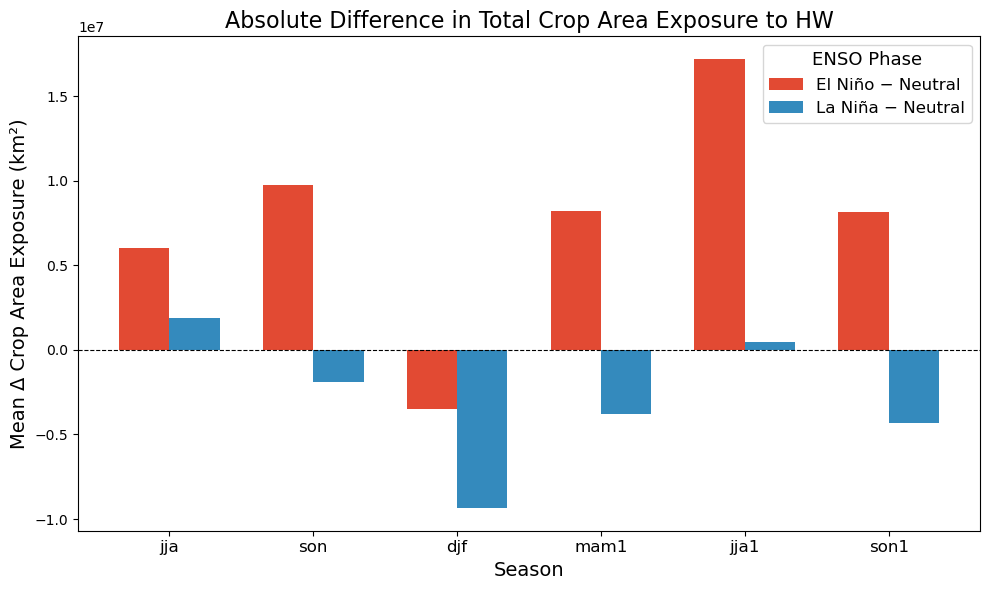

In [8]:
# X locations
x = np.arange(len(season_order))
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# El Niño vs Neutral
ax.bar(
    x - width/2,
    crop_areas_hw_mean['el_minus_ne'],
    width,
    label='El Niño − Neutral',
    color='#E24A33'
)

# La Niña vs Neutral
ax.bar(
    x + width/2,
    crop_areas_hw_mean['la_minus_ne'],
    width,
    label='La Niña − Neutral',
    color='#348ABD'
)

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('Mean Δ Crop Area Exposure (km²)', fontsize=14)
ax.set_title('Absolute Difference in Total Crop Area Exposure to HW', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Legend
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)

plt.tight_layout()
plt.show()

In [9]:
crop_areas_hw_mean['el_minus_ne_rel'] = (crop_areas_hw_mean['el_mean'] - crop_areas_hw_mean['ne_mean'])*100/crop_areas_hw_mean['ne_mean']
crop_areas_hw_mean['la_minus_ne_rel'] = (crop_areas_hw_mean['la_mean'] - crop_areas_hw_mean['ne_mean'])*100/crop_areas_hw_mean['ne_mean']
crop_areas_hw_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne,el_minus_ne_rel,la_minus_ne_rel
0,jja,1.939199e+07,1.521319e+07,1.334361e+07,6.048380e+06,1.869576e+06,45.327910,14.011020
1,son,2.562284e+07,1.398622e+07,1.588641e+07,9.736430e+06,-1.900192e+06,61.287795,-11.961114
2,djf,3.054978e+07,2.465554e+07,3.401520e+07,-3.465424e+06,-9.359658e+06,-10.187868,-27.516103
3,mam1,2.463321e+07,1.263820e+07,1.643929e+07,8.193917e+06,-3.801090e+06,49.843484,-23.121981
4,jja1,2.820409e+07,1.147966e+07,1.100353e+07,1.720057e+07,4.761339e+05,156.318686,4.327103
5,son1,2.473910e+07,1.225380e+07,1.659145e+07,8.147652e+06,-4.337648e+06,49.107528,-26.143871


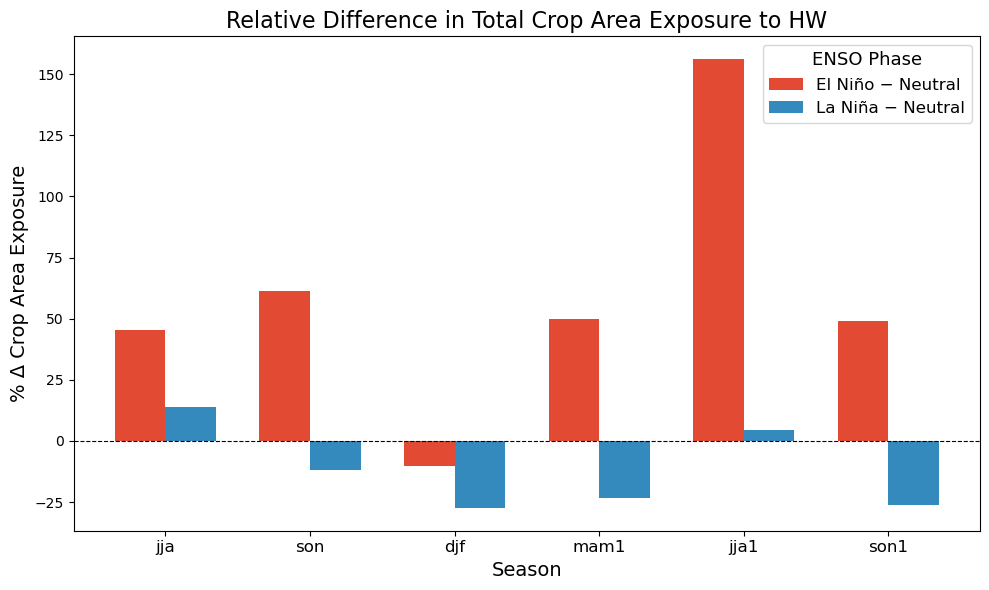

In [10]:
# X locations
x = np.arange(len(season_order))
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# El Niño vs Neutral
ax.bar(
    x - width/2,
    crop_areas_hw_mean['el_minus_ne_rel'],
    width,
    label='El Niño − Neutral',
    color='#E24A33'
)

# La Niña vs Neutral
ax.bar(
    x + width/2,
    crop_areas_hw_mean['la_minus_ne_rel'],
    width,
    label='La Niña − Neutral',
    color='#348ABD'
)

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=14)
ax.set_title('Relative Difference in Total Crop Area Exposure to HW', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Legend
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)

plt.tight_layout()
plt.show()

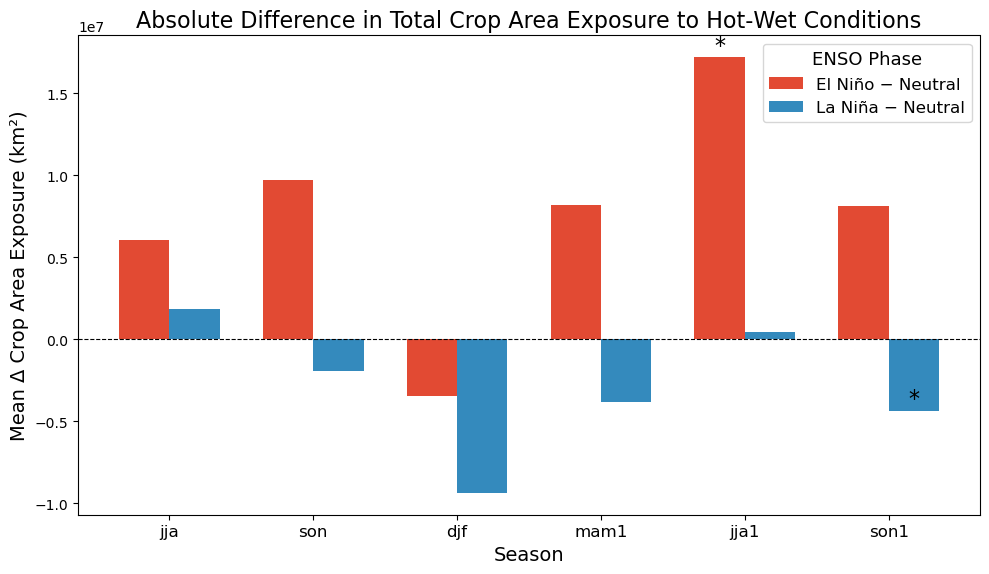

In [11]:
# 1. Prepare x locations and bar width
x = np.arange(len(season_order))
width = 0.35

# 2. Extract bar heights
el_vals = crop_areas_hw_mean['el_minus_ne'].values
la_vals = crop_areas_hw_mean['la_minus_ne'].values

# 3. Build the basic bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_vals, width, label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_vals, width, label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# choose a small offset above the tallest bar for the star
ymax = max(np.max(el_vals), np.max(la_vals))
offset = ymax * 0.001  #at some height above bar

for i, season in enumerate(season_order):
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]
    
    # El Niño star
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,     # x coordinate: center of the El Niño bar
            el_vals[i] + offset,  # y coordinate: top of bar + offset
            '*', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=16
        )
    # La Niña star
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_vals[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final plot tweaks
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('Mean Δ Crop Area Exposure (km²)', fontsize=14)
ax.set_title('Absolute Difference in Total Crop Area Exposure to Hot‑Wet Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)
plt.tight_layout()
plt.show()

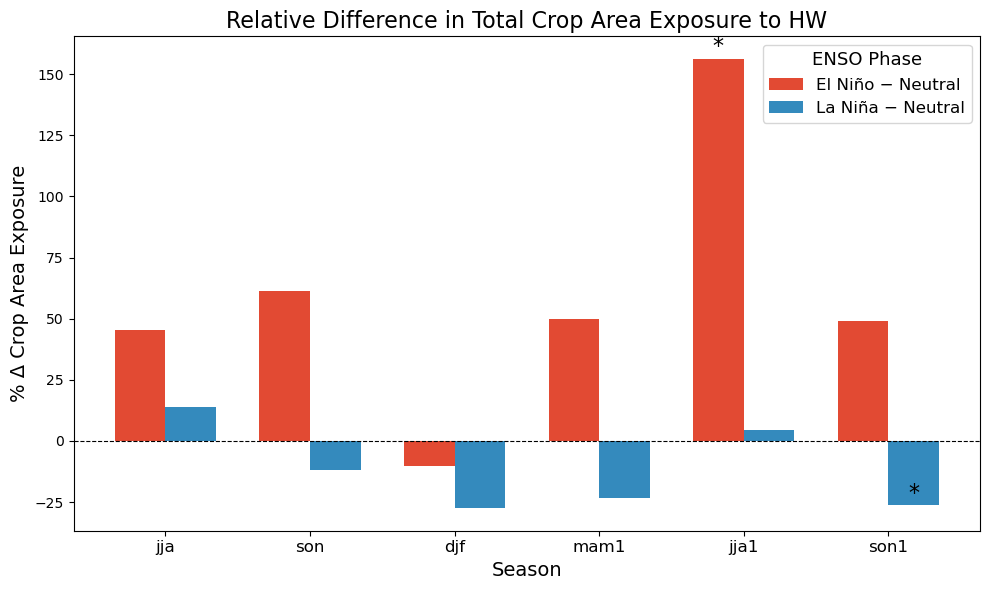

In [12]:
# 1. Prepare x locations and width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['MAM(0)', 'JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)']

# 2. Extract relative differences in the correct season order
el_rel = crop_areas_hw_mean['el_minus_ne_rel'].values
la_rel = crop_areas_hw_mean['la_minus_ne_rel'].values

# 3. Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_rel, width,
                 label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_rel, width,
                 label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# pick an offset as a small fraction of the tallest bar
ymax = max(el_rel.max(), la_rel.max())
offset = ymax * 0.001  # 0.1% of max bar height

for i, season in enumerate(season_order):
    # get p-values for this season
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]

    # annotate El Niño bar
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,
            el_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )
    # annotate La Niña bar
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final styling
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=14)
ax.set_title('Relative Difference in Total Crop Area Exposure to HW', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)
plt.tight_layout()
plt.show()

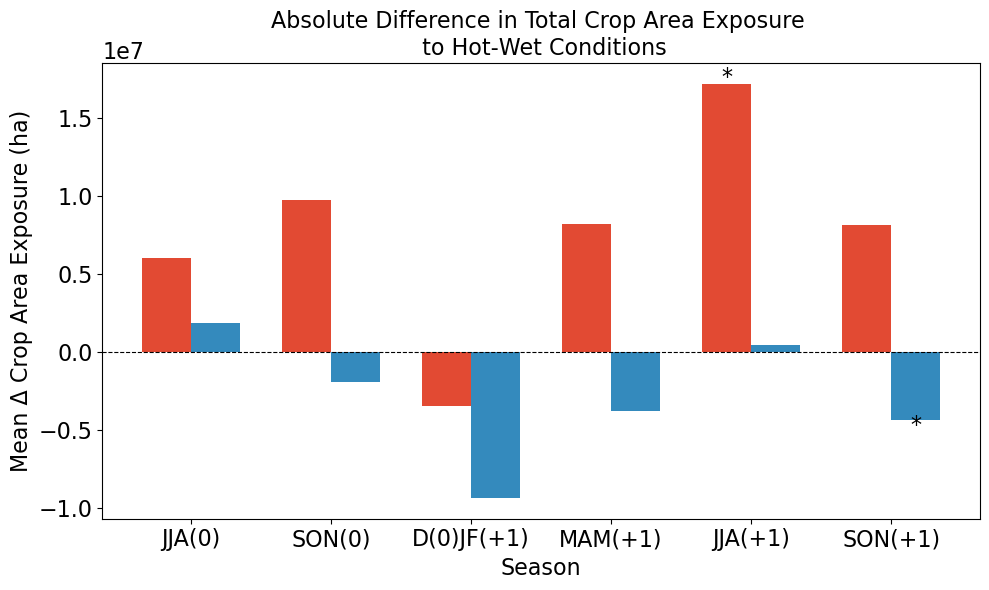

In [13]:
# 1. Prepare x locations and bar width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract bar heights
el_vals = crop_areas_hw_mean['el_minus_ne'].values
la_vals = crop_areas_hw_mean['la_minus_ne'].values

# 3. Build the basic bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_vals, width, label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_vals, width, label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# choose a small offset above the tallest bar for the star
ymax = max(np.max(el_vals), np.max(la_vals))
offset = ymax * -0.02  #at some height above bar

for i, season in enumerate(season_order):
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]
    
    # El Niño star
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,     # x coordinate: center of the El Niño bar
            el_vals[i] + offset,  # y coordinate: top of bar + offset
            '*', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=16
        )
    # La Niña star
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_vals[i] - offset,
            '*',
            ha='center',
            va='top',
            color='black',
            fontsize=16
        )

# 5. Final plot tweaks
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('Mean Δ Crop Area Exposure (ha)', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.set_title('Absolute Difference in Total Crop Area Exposure \n to Hot‑Wet Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

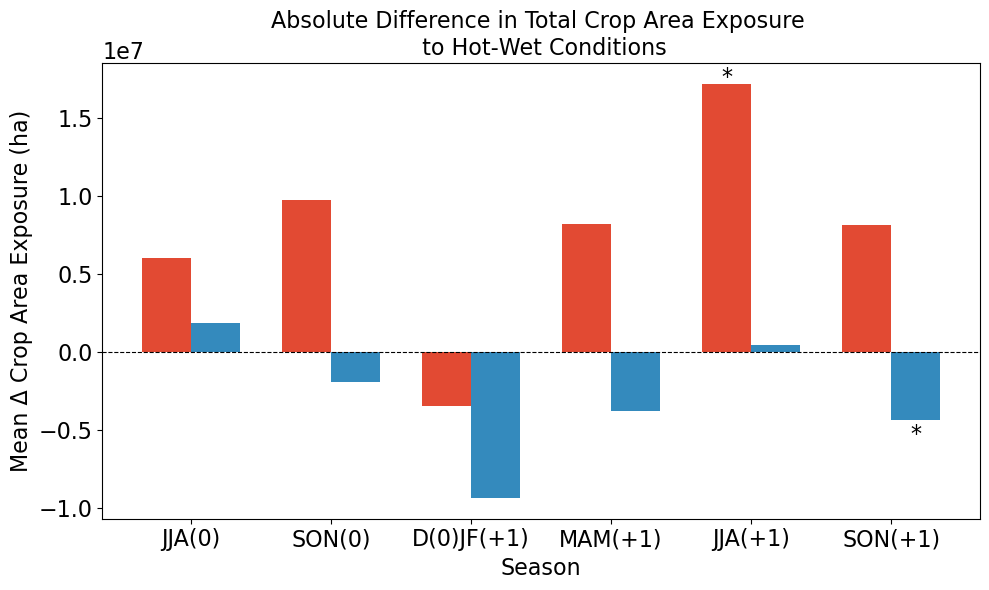

In [14]:
# 1. Prepare x locations and bar width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract bar heights
el_vals = crop_areas_hw_mean['el_minus_ne'].values
la_vals = crop_areas_hw_mean['la_minus_ne'].values

# 3. Build the basic bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_vals, width, label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_vals, width, label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# choose a small offset above the tallest bar for the star
ymax = max(np.max(el_vals), np.max(la_vals))
ymin = min(np.min(el_vals), np.min(la_vals))
offset_pos = ymax * -0.02           # 2% of the top
offset_neg = abs(ymin) * 0.02      # 2% of the bottom

for i, season in enumerate(season_order):
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]
    
    # El Niño star
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,     # x coordinate: center of the El Niño bar
            el_vals[i] + offset_pos,  # y coordinate: top of bar + offset
            '*', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=16
        )
    # La Niña star
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_vals[i] - offset_neg,
            '*',
            ha='center',
            va='top',
            color='black',
            fontsize=16
        )

# 5. Final plot tweaks
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('Mean Δ Crop Area Exposure (ha)', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.set_title('Absolute Difference in Total Crop Area Exposure \n to Hot‑Wet Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

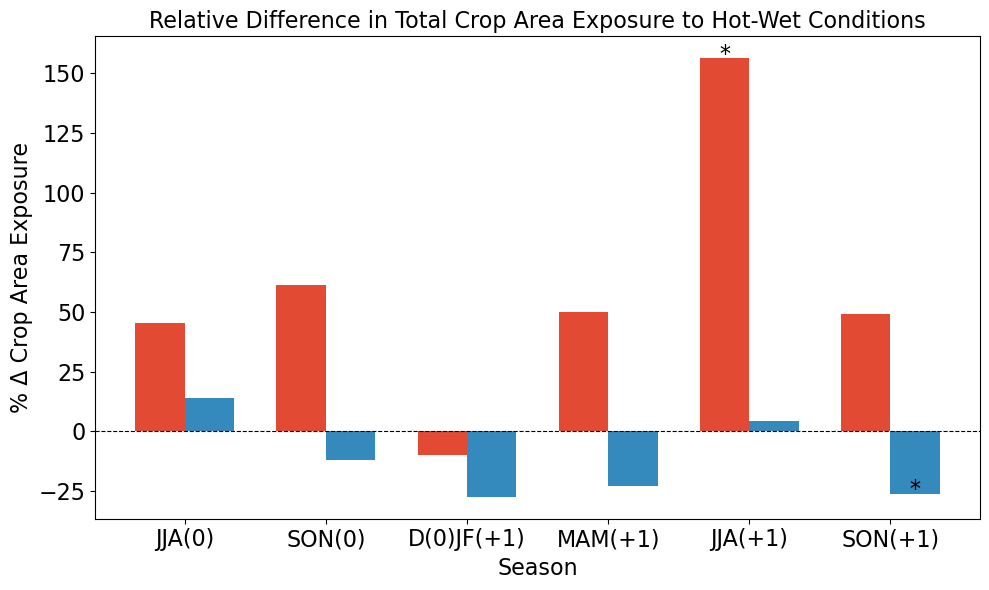

In [15]:
# 1. Prepare x locations and width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract relative differences in the correct season order
el_rel = crop_areas_hw_mean['el_minus_ne_rel'].values
la_rel = crop_areas_hw_mean['la_minus_ne_rel'].values

# 3. Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_rel, width,
                 label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_rel, width,
                 label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# pick an offset as a small fraction of the tallest bar
ymax = max(el_rel.max(), la_rel.max())
offset = ymax * -0.02  # 0.1% of max bar height

for i, season in enumerate(season_order):
    # get p-values for this season
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]

    # annotate El Niño bar
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,
            el_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )
    # annotate La Niña bar
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final styling
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('Relative Difference in Total Crop Area Exposure to Hot-Wet Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

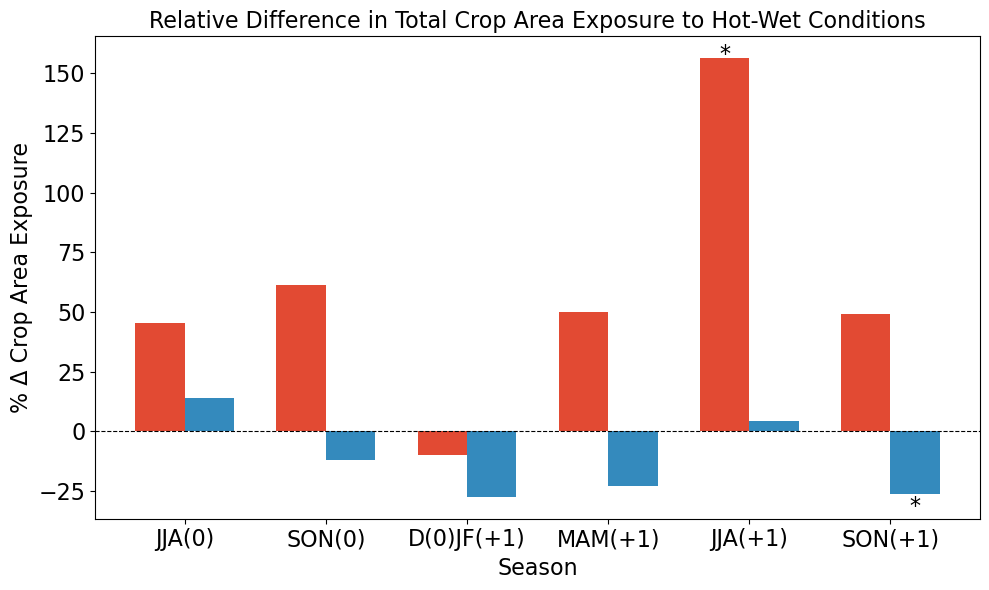

In [16]:
# 1. Prepare x locations and width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract relative differences in the correct season order
el_rel = crop_areas_hw_mean['el_minus_ne_rel'].values
la_rel = crop_areas_hw_mean['la_minus_ne_rel'].values

# 3. Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_rel, width,
                 label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_rel, width,
                 label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# pick an offset as a small fraction of the tallest bar
ymax = max(np.max(el_rel), np.max(la_rel))
ymin = min(np.min(el_rel), np.min(la_rel))
offset_pos = ymax * -0.02           # 2% of the top
offset_neg = abs(ymin) * -0.02      # 2% of the bottom

for i, season in enumerate(season_order):
    # get p-values for this season
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]

    # annotate El Niño bar
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,
            el_rel[i] + offset_pos,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )
    # annotate La Niña bar
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_rel[i] + offset_neg,
            '*',
            ha='center',
            va='top',
            color='black',
            fontsize=16
        )

# 5. Final styling
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('Relative Difference in Total Crop Area Exposure to Hot-Wet Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
crop_areas_hw_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne,el_minus_ne_rel,la_minus_ne_rel
0,jja,1.939199e+07,1.521319e+07,1.334361e+07,6.048380e+06,1.869576e+06,45.327910,14.011020
1,son,2.562284e+07,1.398622e+07,1.588641e+07,9.736430e+06,-1.900192e+06,61.287795,-11.961114
2,djf,3.054978e+07,2.465554e+07,3.401520e+07,-3.465424e+06,-9.359658e+06,-10.187868,-27.516103
3,mam1,2.463321e+07,1.263820e+07,1.643929e+07,8.193917e+06,-3.801090e+06,49.843484,-23.121981
4,jja1,2.820409e+07,1.147966e+07,1.100353e+07,1.720057e+07,4.761339e+05,156.318686,4.327103
5,son1,2.473910e+07,1.225380e+07,1.659145e+07,8.147652e+06,-4.337648e+06,49.107528,-26.143871
